In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

: 

# Section 1 — Supervised Learning: Regression
## Predicting taxi tip_amount (NYC Yellow Taxi)
Each row is a completed taxi trip. Your goal is to predict the tip a passenger leaves (tip_amount, a continuous value) from the trip's characteristics. The available columns are:

VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount

### Part 1.1 — Load and explore the taxi data

In [ ]:
taxi = pd.read_csv(TAXI_URL)

taxi.shape


(41202, 13)

In [ ]:
taxi.head()

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [ ]:
taxi.info()


<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


In [ ]:
taxi.describe()


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


In [ ]:
# - count missing values per column
taxi.isna().sum()

VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64

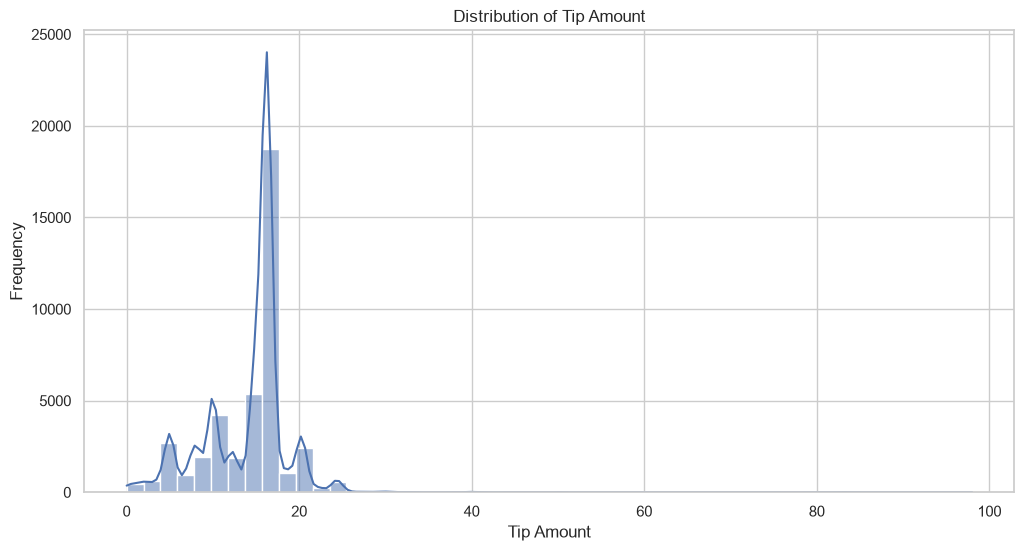

In [ ]:
# Visualise the distribution of the target `tip_amount`
plt.figure(figsize=(12, 6))
sns.histplot(taxi["tip_amount"], bins=50, kde=True)

plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")

plt.show()



Student Reasoning — Taxi data exploration What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

Answer: The dataset had 41,202 rows and 13 columns and there were no missing values. The minimum tip_amount is 0.01, the maximum is 98.00, and the mean is 14.10 meaning there are no negative tips but there are outliers that ull the mean up. The distribution is right skewed and this suggests that extreme outliers may influence model training, and that rows with values zero or negative trip_distance and fare_amount should be removed during processing.

### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [ ]:
# Handle missing / invalid rows
taxi = taxi[taxi["trip_distance"] > 0]
taxi = taxi[taxi["fare_amount"] > 0]

# Drop zero-information columns
taxi = taxi.drop(columns=["VendorID", "payment_type"])

# Feature engineering — create at least ONE new, justified feature
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

#  Decide which columns are categorical
cat_cols = ["RatecodeID", "store_and_fwd_flag"]
taxi = pd.get_dummies(taxi, columns=cat_cols, drop_first=True)

print(taxi.shape)
print(taxi.head())


(41126, 14)
   passenger_count  trip_distance  PULocationID  DOLocationID  fare_amount  \
0                1          17.63           132           164         70.0   
1                1          19.52           132           236         70.0   
2                1          17.81           132            48         70.0   
3                2          19.30           132           148         70.0   
4                1          18.75           132           234         70.0   

   mta_tax  tolls_amount  improvement_surcharge  tip_amount  fare_per_mile  \
0      0.5          6.94                      1       16.54       3.970505   
1      0.5          6.94                      1       16.19       3.586066   
2      0.5          6.94                      1       12.00       3.930376   
3      0.5          0.00                      1        5.00       3.626943   
4      0.5          6.94                      1       10.00       3.733333   

   RatecodeID_2  RatecodeID_4  RatecodeID_5  store

**Student Reasoning — Taxi preprocessing** 1. How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?

Answer: 1. There were no missing values. Rows where trip_distance or fare_amount were zero or negative were dropped as they represent inaccurate trips that would mislead the model by introducing noise.

2. A fair_per_mile feature was created by dividing fair_amount by trip_distance. The intuition behind it is that the more expensive trips per mile may correlate with higher tips. It does no use tip_amount so there is no data leakage. VendorID and payment_type were also dropped because they had only one unique value and no information.

3. StandardScaler will be used to equalize each feature to mean 0 and standard deviation 1. This is appropriate because features like fare_amount and trip_distance are on very different scales and the Linear Regression model is sensitive to that.



### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y = tip_amount)
X = taxi.drop(columns=["tip_amount"])
y = taxi["tip_amount"]

# Split into train / validation / test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)

# Fit your scaler on the TRAINING set only, then transform train, val, and test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (24675, 13)
Validation: (8225, 13)
Test: (8226, 13)


**Student Reasoning — Splitting** What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?

Answer: A 60/20/20 split was used. 60% for training, 20% for validation, and 20% for testing. A separate validation set is useful because it allows you to tune hyperparameters and compare models during development without touching the test set. If you used the test set for tuning, it would no longer be an unbiased final check, the model would have indirectly been optimised for it. The scaler must be fit on training data only because fitting it on the full dataset would let it learn the mean and standard deviation of the validation and test sets, meaning the model has indirectly seen those sets before evaluation. This is data leakage and leads to falsely optimistic results.



### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on train, validation, and test sets.

Linear Regression: 
Train RMSE: 4.804452555330035, R2: 0.051327956775104044
Validation RMSE: 5.037135953076983, R2: 0.04863478237663166
Test  RMSE: 5.013178952774091, R2: 0.0510620492123568
Decision Tree: 
Train RMSE: 4.785265747231785, R2: 0.05888996013854586
Validation RMSE: 5.069767489670506, R2: 0.036268602326716026
Test  RMSE: 5.035670622511941, R2: 0.04252811199860018


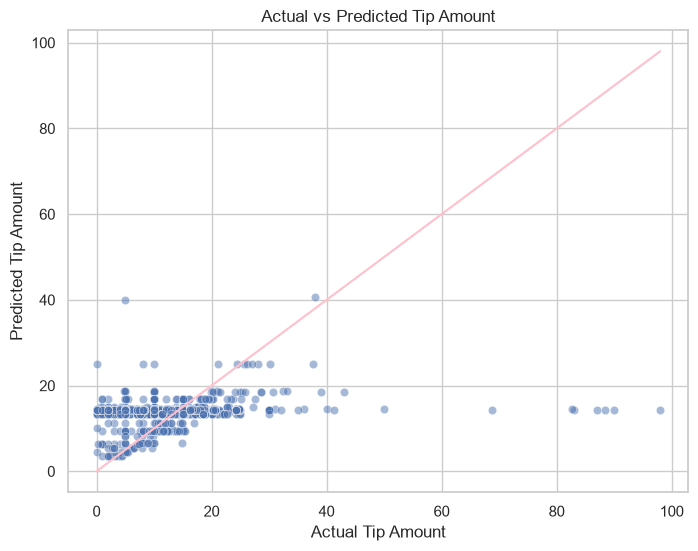

In [ ]:
# Import, initialise, and train a regression model.
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Model 1 : Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predict on train, validation, and test sets.
model_lr_train_pred = model_lr.predict(X_train)
model_lr_val_pred = model_lr.predict(X_val)
model_lr_test_pred = model_lr.predict(X_test)

# Report RMSE and R^2 for ALL THREE sets.
print("Linear Regression: ")
print(
    f"Train RMSE: {mean_squared_error(y_train, model_lr_train_pred) ** 0.5}, R2: {r2_score(y_train, model_lr_train_pred)}"
)
print(
    f"Validation RMSE: {mean_squared_error(y_val, model_lr_val_pred) ** 0.5}, R2: {r2_score(y_val, model_lr_val_pred)}"
)
print(
    f"Test  RMSE: {mean_squared_error(y_test, model_lr_test_pred) ** 0.5}, R2: {r2_score(y_test, model_lr_test_pred)}"
)

# Model 2: Decision Tree
model_dt = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)

# Predict on train, validation, and test sets.
model_dt_train_pred = model_dt.predict(X_train)
model_dt_val_pred = model_dt.predict(X_val)
model_dt_test_pred = model_dt.predict(X_test)

# Report RMSE and R^2 for ALL THREE sets.
print("Decision Tree: ")
print(
    f"Train RMSE: {mean_squared_error(y_train, model_dt_train_pred) ** 0.5}, R2: {r2_score(y_train, model_dt_train_pred)}"
)
print(
    f"Validation RMSE: {mean_squared_error(y_val, model_dt_val_pred) ** 0.5}, R2: {r2_score(y_val, model_dt_val_pred)}"
)
print(
    f"Test  RMSE: {mean_squared_error(y_test, model_dt_test_pred) ** 0.5}, R2: {r2_score(y_test, model_dt_test_pred)}"
)


# Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=model_dt_test_pred, alpha=0.5)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="pink")

plt.title("Actual vs Predicted Tip Amount")
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.show()


**Student Reasoning — Regression evaluation & overfitting** 1. Which model performed best on the validation set, and which hyper-parameters did you try? 2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 3. What would you change to reduce overfitting if you saw it?

Answer: 1. Linear Regression performed marginally better on the validation set (R² = 0.0486) compared to the Decision Tree with max_depth=5 (R² = 0.0363). Different max_depth values were considered, but increasing tree depth was avoided to prevent further overfitting given the already limited signal in the data.

2. Linear Regression shows train, validation, and test R² values that are nearly identical (0.0513, 0.0486, 0.0511), indicating no overfitting but the very low R² overall indicates underfitting, as the model is too simple or the features are too weak to capture what motivates tipping. The Decision Tree shows a small gap between train R² (0.0589) and validation/test R² (0.0363, 0.0425), suggesting mild overfitting, but the gap is small. Overall, the dominant problem in this task is underfitting/low signal rather than overfitting.


3. Since underfitting is the dominant issue rather than overfitting, the priority would be richer features rather than simpler models. For instance, trip duration, or payment method, which strongly influences whether a tip is recorded at all. For the Decision Tree's mild overfitting specifically, reducing max_depth further or using an ensemble method like Random Forest could help.

# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (NObeyesdad)
Each row describes a person's eating habits and physical condition. Predict their obesity category NObeyesdad, which has 7 classes: Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III.

Feature columns: Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP, CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS.

### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the class balance of the target.

In [ ]:
# Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)
obesity.shape

(2111, 17)

In [ ]:
obesity.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
obesity.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [ ]:
obesity.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [ ]:
obesity.isna().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


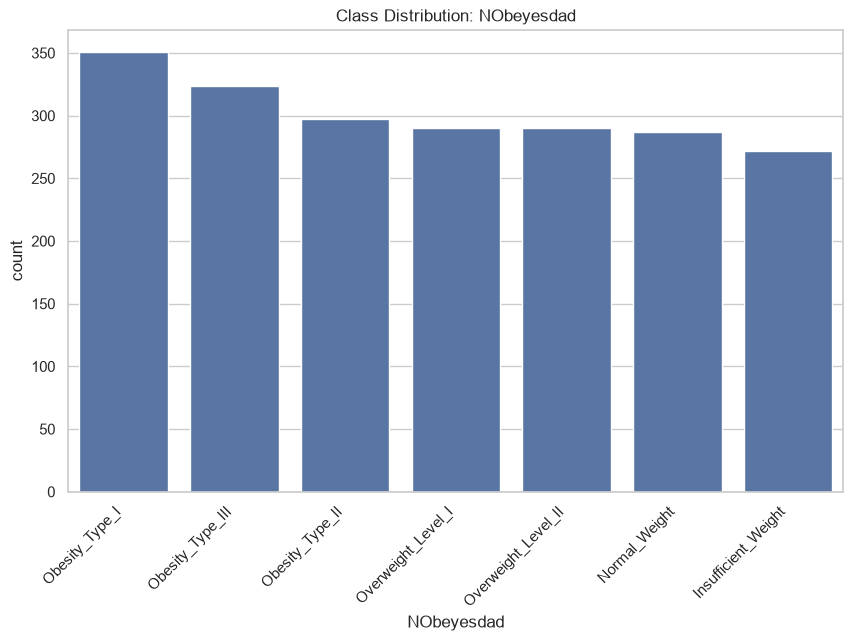

In [ ]:
# Show the class distribution of `NObeyesdad`
print(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(
    x="NObeyesdad", data=obesity, order=obesity["NObeyesdad"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution: NObeyesdad")
plt.show()

**Student Reasoning — Obesity data exploration** How many rows/features are there? Which columns are categorical vs numeric? Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?

Answer: The dataset has 2,111 rows and 17 columns with 16 features and 1 target. Eight columns are numeric (Age, Height, Weight, FCVC, NCP, CH2O, FAF, TUE) and eight are categorical (Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS). There are no missing values. The target NObeyesdad is well balanced across all 7 classes, ranging from 272 (Insufficient_Weight) to 351 (Obesity_Type_I) with a difference of only 79 rows. Class balance matters because a heavily imbalanced dataset can lead a model to simply predict the majority class most of the time, achieving high accuracy while completely failing on minority classes. Here the balance is good enough that this is not a major concern.

### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical columns.

# Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

# Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS).
caec_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity["CAEC"] = obesity["CAEC"].map(caec_order)
obesity["CALC"] = obesity["CALC"].map(calc_order)

obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"], drop_first=True)

# engineer a domain feature
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# Encode the target `NObeyesdad` into integer class labels
le = LabelEncoder()
obesity["NObeyesdad"] = le.fit_transform(obesity["NObeyesdad"])

print(obesity.head())
print(obesity.columns.tolist())


    Age  Height  Weight  family_history_with_overweight  FAVC  FCVC  NCP  \
0  21.0    1.62    64.0                               1     0   2.0  3.0   
1  21.0    1.52    56.0                               1     0   3.0  3.0   
2  23.0    1.80    77.0                               1     0   2.0  3.0   
3  27.0    1.80    87.0                               0     0   3.0  3.0   
4  22.0    1.78    89.8                               0     0   2.0  1.0   

   CAEC  SMOKE  CH2O  SCC  FAF  TUE  CALC  NObeyesdad  Gender_Male  \
0     1      0   2.0    0  0.0  1.0     0           1        False   
1     1      1   3.0    1  3.0  0.0     1           1        False   
2     1      0   2.0    0  2.0  1.0     2           1         True   
3     1      0   2.0    0  2.0  0.0     2           5         True   
4     1      0   2.0    0  0.0  0.0     1           6         True   

   MTRANS_Bike  MTRANS_Motorbike  MTRANS_Public_Transportation  \
0        False             False                        

**Student Reasoning — Obesity preprocessing** 1. How did you encode each type of categorical variable, and why? 2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. 3. Which scaler did you use and why?

Answer: 1. Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) were mapped directly to 1/0 since there are only two values and no ordering is lost. Ordinal columns (CAEC, CALC) were assigned ordered integers (0-3: no, Sometimes, Frequently, Always) to preserve their natural ordering. Nominal columns (Gender, MTRANS) were encoded with get_dummies since they have no natural order and assigning arbitrary numbers would mislead the model.


2. BMI was engineered as Weight divided by Height squared. It is a good feature since obesity level is clinically defined using BMI thresholds. However including it makes the task somewhat easier than it would be in a real scenario where only raw measurements are available. It is included here as it is a legitimate derivable feature from the available columns and does not directly use the target.


3. StandardScaler was used, fitted on training data only. It is appropriate here because numeric features like Age, Weight, and Height are on different scales, and models like Logistic Regression are sensitive to feature scale differences.

### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [ ]:
# Separate X (features) and y (encoded NObeyesdad)
X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]

# Split into train / validation / test using stratify=y so every split has all 7 classes
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

# Fit the scaler on the training set only, then transform train / val / test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (1266, 20)
Validation: (422, 20)
Test: (423, 20)


**Student Reasoning — Splitting** What split ratio did you choose? Why is stratify=y important for this dataset? What could go wrong if you split without stratifying?

Answer: A 60/20/20 split was used. stratify=y is important because with 7 classes and only 2,111 rows, a purely random split could accidentally under-represent or completely exclude a class from the validation or test set. This would make evaluation unreliable. Stratification ensures each split contains roughly the same proportion of each class as the full dataset, giving a fair and representative evaluation across all 7 obesity levels.

### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on train, validation, and test.



Logistic Regression
Train Accuracy: 0.9241706161137441, Macro-F1: 0.9216924878748501
Validation Accuracy: 0.8791469194312796, Macro-F1: 0.8728259358673748
Test Accuracy: 0.8936170212765957, Macro-F1: 0.8895425359817121
Random Forest
Train Accuracy: 1.0, Macro-F1: 1.0
Validation Accuracy: 0.9928909952606635, Macro-F1: 0.9925195748154264
Test Accuracy: 0.9952718676122931, Macro-F1: 0.9954565354928734
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        54
      Normal_Weight       1.00      1.00      1.00        58
     Obesity_Type_I       0.99      1.00      0.99        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1

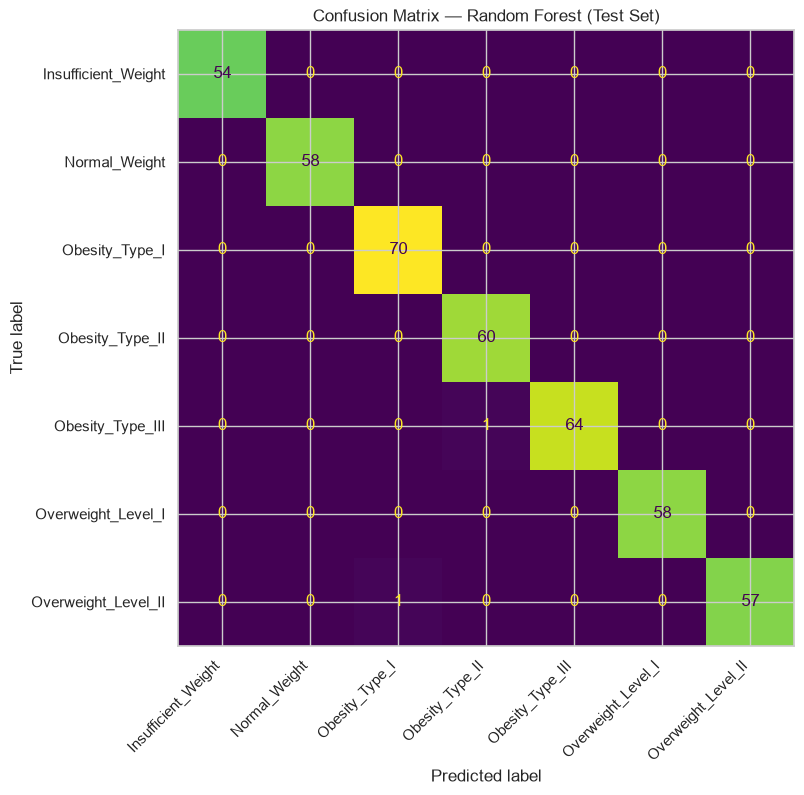

In [ ]:
# Import, initialise, and train a classifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Model 1: Logistic Regression
model_lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model_lr_clf.fit(X_train, y_train)

# Predict on train, validation, and test
model_lr_train_pred = model_lr_clf.predict(X_train)
model_lr_val_pred = model_lr_clf.predict(X_val)
model_lr_test_pred = model_lr_clf.predict(X_test)

# Report accuracy AND macro-F1 for ALL THREE sets
print("Logistic Regression")
print(
    f"Train Accuracy: {accuracy_score(y_train, model_lr_train_pred)}, Macro-F1: {f1_score(y_train, model_lr_train_pred, average='macro')}"
)
print(
    f"Validation Accuracy: {accuracy_score(y_val, model_lr_val_pred)}, Macro-F1: {f1_score(y_val, model_lr_val_pred, average='macro')}"
)
print(
    f"Test Accuracy: {accuracy_score(y_test, model_lr_test_pred)}, Macro-F1: {f1_score(y_test, model_lr_test_pred, average='macro')}"
)

# Model 2: Random Forest
model_rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
model_rf_clf.fit(X_train, y_train)

model_rf_train_pred = model_rf_clf.predict(X_train)
model_rf_val_pred = model_rf_clf.predict(X_val)
model_rf_test_pred = model_rf_clf.predict(X_test)

# Report accuracy AND macro-F1 for ALL THREE sets
print("Random Forest")
print(
    f"Train Accuracy: {accuracy_score(y_train, model_rf_train_pred)}, Macro-F1: {f1_score(y_train, model_rf_train_pred, average='macro')}"
)
print(
    f"Validation Accuracy: {accuracy_score(y_val, model_rf_val_pred)}, Macro-F1: {f1_score(y_val, model_rf_val_pred, average='macro')}"
)
print(
    f"Test Accuracy: {accuracy_score(y_test, model_rf_test_pred)}, Macro-F1: {f1_score(y_test, model_rf_test_pred, average='macro')}"
)

# classification_report
print(classification_report(y_test, model_rf_test_pred, target_names=le.classes_))

# Show a confusion matrix for the test set
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, model_rf_test_pred, display_labels=le.classes_, ax=ax, colorbar=False
)
plt.xticks(rotation=45, ha="right")
plt.title("Confusion Matrix — Random Forest (Test Set)")
plt.show()



**Student Reasoning — Classification evaluation & overfitting** 1. Which classifier did you choose and why? 2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. 3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?

Answer: 1. Two classifiers were trained which were Logistic Regression and Random Forest. Random Forest was chosen as the better model because it can capture non-linear boundaries between the 7 obesity classes, whereas Logistic Regression assumes linear decision boundaries which may not hold across all class pairs.


2. Random Forest achieved perfect train accuracy (1.000) and F1 (1.000), indicating it memorized the training data completely. However validation accuracy (0.993) and test accuracy (0.995) remain extremely high, with a train-to-test gap of only 0.005. While technically overfitting is present, it is practically negligible and the model generalizes almost perfectly. Logistic Regression shows a slightly larger gap (train 0.924 vs test 0.894) but still performs well. Random Forest is the better model overall.


3. The only misclassifications occurred between Obesity_Type_II and Obesity_Type_III, and between Overweight_Level_II and Obesity_Type_I. These are adjacent severity categories whose BMI ranges sit closest to each other, making the decision boundary between them the hardest to learn. All other classes were classified perfectly.

# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data
Now pretend you never had the NObeyesdad labels. Using only the scaled feature matrix from Section 2, use K-Means to see whether people naturally fall into distinct profiles — and then compare those clusters to the real obesity levels.

### Part 3.1 — Choose k, fit K-Means, and visualise

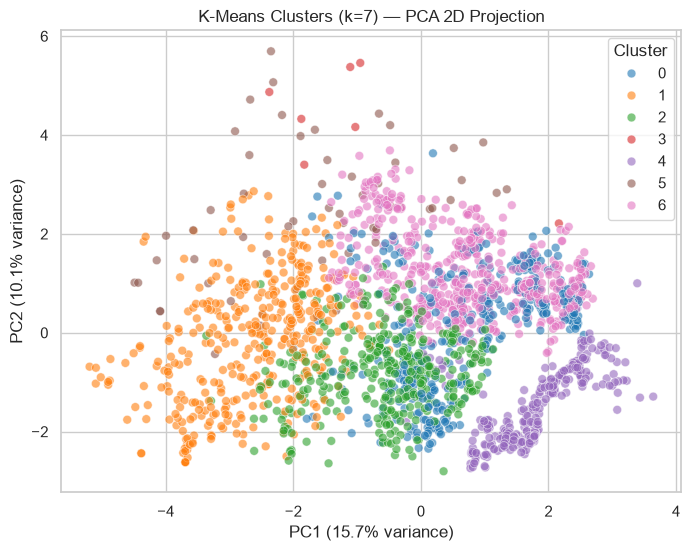

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ONLY the scaled obesity features (no target) for clustering.
X_cluster = scaler.transform(obesity.drop(columns=["NObeyesdad"]))

# Choose the number of clusters k with the Elbow method
inertia = []
silhouette = []
k_range = range(2, 11)

# Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_cluster, km.labels_))

# Visualise the clusters in 2D
# Fit KMeans with k=7
km_final = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)

# Reduce to 2D with PCA for visualisation
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

# Plot clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette="tab10", alpha=0.6, s=40
)
plt.title("K-Means Clusters (k=7) — PCA 2D Projection")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend(title="Cluster")
plt.show()


In [ ]:
# Build a crosstab
obesity_copy = obesity.copy()
obesity_copy["cluster"] = cluster_labels
obesity_copy["true_label"] = le.inverse_transform(obesity["NObeyesdad"])

crosstab = pd.crosstab(obesity_copy["cluster"], obesity_copy["true_label"])
print(crosstab)

true_label  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
cluster                                                          
0                             0             22             109   
1                           188            149               2   
2                             3             38             109   
3                             0              4               0   
4                             0              0               4   
5                             6             32               2   
6                            75             42             125   

true_label  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
cluster                                                             
0                       100                 0                  57   
1                         1                 0                  40   
2                        48                 0                  88   
3                         1                 0               

**Student Reasoning — Clustering** 1. How did you choose k? Quote the Elbow/silhouette evidence. 2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down? 3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?

Answer: 1. The elbow method showed a gradual, steady decrease in inertia from k=2 to k=10 with no sharp elbow, suggesting the data does not have one obviously dominant number of clusters. The silhouette score peaked at k=2 (0.18), indicating the cleanest global separation is into two broad groups. However k=7 was chosen to match the number of known obesity categories, enabling a direct comparison between unsupervised clusters and real labels. The silhouette score at k=7 (0.138) was reasonable, and the elbow curve showed diminishing returns beyond that point.


2. The clusters partially align with the real labels. Cluster 4 maps almost perfectly to Obesity_Type_III (324 out of 330 members), and Cluster 1 captures most Insufficient_Weight and Normal_Weight cases. However the middle obesity categories (Obesity_Type_I, Obesity_Type_II, Overweight_Level_I, Overweight_Level_II) are heavily mixed across Clusters 0, 2, and 6, meaning K-Means could not cleanly separate them without label information. This makes sense as adjacent obesity levels have overlapping feature distributions.


3. In a real setting where obesity labels are expensive to collect (requiring clinical assessment), these clusters could be used to quickly segment a population into broad risk groups using only easily measured features like height, weight, and lifestyle habits. The algorithm reliably identifies extreme cases like severely obese or underweight which are often the most urgent for intervention. The mixed middle clusters could still flag individuals at higher risk for further clinical evaluation, reducing the need to assess every person individually.



# Section 4 — Reflection
Answer in a few sentences each:

1. Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
The Random Forest classifier learned precise decision boundaries between all 7 obesity levels because it was trained with labeled examples showing exactly which features correspond to which category. K-means could not do this becase without labels it could not it had no way to know that Overweight_Level_I and Overweight_Level_II are distinct categories, and so it merged them into the same cluster. However K-Means independently identified extreme obesity and underweight as the most distinct groups, which is a meaningful finding that requires no human annotation at all.

2. Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
Regression on tip_amount used RMSE and R² as metrics. RMSE measures the average dollar error in predictions, giving an interpretable sense of how far off the model is in real-world units. R² measures how much of the variation in tips the model explains. Classification on obesity level used accuracy and macro-F1. Accuracy counts the percentage of correctly predicted classes, while macro-F1 accounts for performance across all 7 classes equally.

3. Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
The biggest train-test gap appeared in the Random Forest classifier, where train accuracy was perfect (1.000) while test accuracy was 0.995. In the regression task both models showed very small train-test gaps, but suffered from severe underfitting rather than overfitting, with R² around 0.05 across all splits. The most effective measure taken to control overfitting was limiting the Decision Tree regressor to max_depth=5, which prevented it from growing deep enough to memorize individual training examples. Using a 60/20/20 three-way split also helped by keeping the test set completely unseen during all model development and tuning decisions.
